In [1]:
!python scripts/01_preprocess_ld2011_2014.py

Répertoire de travail : C:\myprojects\OPxGNN\dataset\dataelectricity

TÂCHE D — CHARGEMENT
Dataset brut : (140256, 371)

TÂCHE E — RÉÉCHANTILLONNAGE 15 min -> 1 h
  Lignes 15 min : 140256 -> horaire : 35065
  NaN avant resample : 0, après resample : 0

TÂCHE F — LABELS DE CLASSIFICATION
  Charge totale (kW) : min=454.5, max=448148.8
  Seuil (95e centile, train) : 360203.93 kW
  Labels : 1827 congestés (1) / 33238 normaux (0) (5.21 % en congestion)

TÂCHE G — SPLIT STRATIFIÉ HORAIRE
TRAIN:
0=23266
1=1279
VAL:
0=4986
1=274
TEST:
0=4986
1=274

NORMALISATION (fit sur train uniquement)
  Plage brute clients : [0.00, 191000.00] kW
  Après MinMax : [0.00, 1.18]
  Total : 35065 | Train : 24545 | Val : 5260 | Test : 5260

SAUVEGARDE
  -> C:\myprojects\OPxGNN\data\processed\load_hourly.csv.gz
  -> C:\myprojects\OPxGNN\data\processed\labels_hourly.csv.gz
  -> C:\myprojects\OPxGNN\data\processed\thresholds.csv
  Fichiers locaux : train/validation/test_data.csv, electricity_normalized_full.csv

SÉQ

In [ ]:
!python scripts/02_graph_topology.py

In [ ]:
!python scripts/05_prepare_pyg_data.py --batch-size 32

In [ ]:
!python scripts/06_gcn_model.py --batch-size 32 --device cuda

In [ ]:
!python scripts/07_train_gcn.py --epochs 5 --batch-size 32 --device cuda --debug-metrics

In [ ]:
!python scripts/08_plot_gcn_history.py

In [ ]:
!python scripts/10_predict_gcn.py --batch-size 64 --device cuda

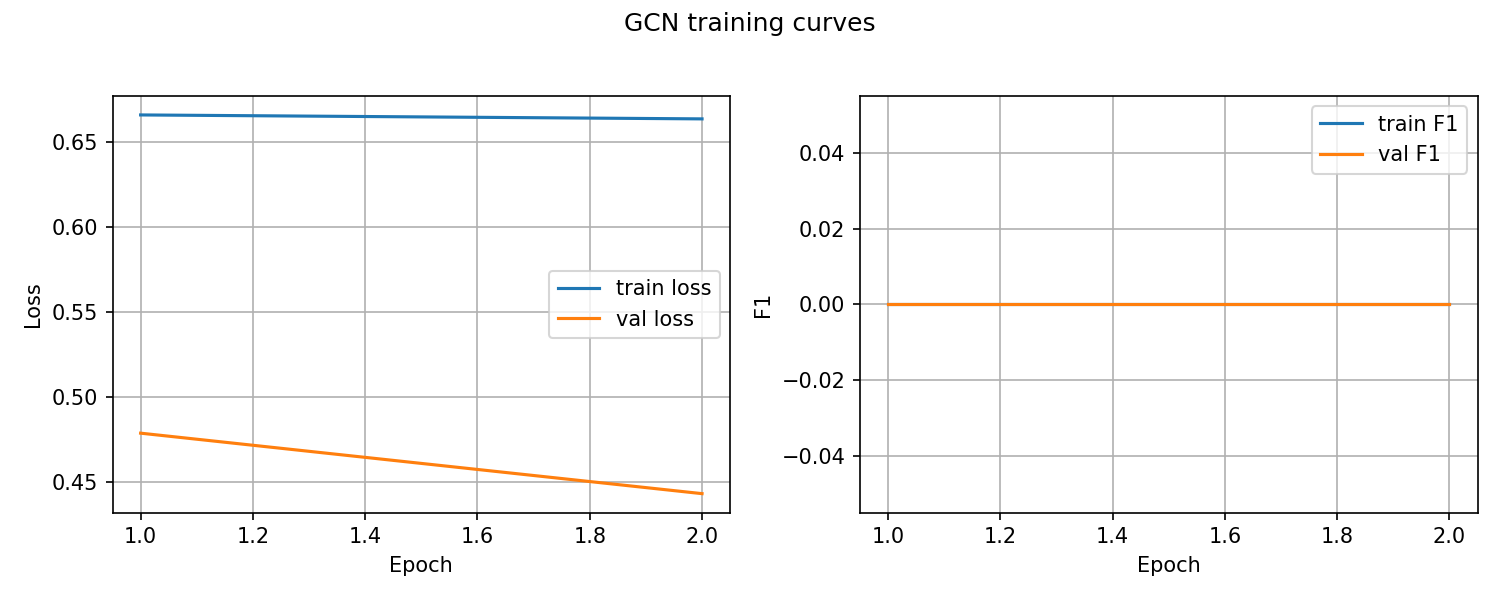

In [2]:
from IPython.display import Image
Image("data/processed/gcn_learning_curves.png")

RUNNING XGBOOST


In [ ]:
!python scripts/03_baseline_xgboost.py --n-trials 50 --cv-folds 5

AFTER EVERYTHING FINISHES

In [ ]:
!ls -lh data/processed
!cat data/processed/gcn_test_metrics.json